In [31]:
import pandas as pd
import pandas_datareader as pdr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
from sklearn.linear_model import LogisticRegression as LR
from sklearn.metrics import roc_auc_score
from optbinning import OptimalBinning as opb
import shap
from scipy.special import expit
import xgboost as xgb

In [32]:
chunks = []
for chunk in pd.read_csv(
    'accepted_2007_to_2018Q4.csv',
    usecols=[
    'loan_amnt', 'term', 'int_rate', 'installment', 'grade',
    'sub_grade', 'emp_length', 'home_ownership', 'annual_inc',
    'verification_status', 'issue_d', 'loan_status', 'purpose',
    'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line',
    'fico_range_low', 'fico_range_high', 'inq_last_6mths',
    'mths_since_last_delinq', 'open_acc', 'pub_rec',
    'revol_bal', 'revol_util', 'total_acc', 'mort_acc',
    'pub_rec_bankruptcies', 'acc_open_past_24mths'],
    parse_dates=['issue_d', 'earliest_cr_line'],
    date_format="%b-%Y",
    chunksize=100000):
    chunks.append(chunk);
data = pd.concat(chunks, ignore_index=True)
data['fico_avg'] = (data['fico_range_high'] + data['fico_range_low']) / 2
data.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,acc_open_past_24mths,mort_acc,pub_rec_bankruptcies,fico_avg
0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,Not Verified,...,30.0,7.0,0.0,2765.0,29.7,13.0,4.0,1.0,0.0,677.0
1,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,Not Verified,...,6.0,22.0,0.0,21470.0,19.2,38.0,4.0,4.0,0.0,717.0
2,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,Not Verified,...,NaN,6.0,0.0,7869.0,56.2,18.0,6.0,5.0,0.0,697.0
3,35000.0,60 months,14.85,829.90,C,C5,10+ years,MORTGAGE,110000.0,Source Verified,...,NaN,13.0,0.0,7802.0,11.6,17.0,2.0,1.0,0.0,787.0
4,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,Source Verified,...,12.0,12.0,0.0,21929.0,64.5,35.0,10.0,6.0,0.0,697.0


In [33]:
df = (
    data.query(
        'loan_status != "Current" and loan_status != "In Grace Period" and loan_status != "Late (16-30 days)"'
        )
    )
df['credit_hist_months'] = ((df['issue_d'] - df['earliest_cr_line']).dt.days // 30)
df = df[df['issue_d'].between('2012-01-01', '2017-12-31')]
df['target'] = np.select(
    condlist=[
        df['loan_status'] == 'Fully Paid',
        df['loan_status'] == 'Charged Off',
        df['loan_status'] == 'Default',
        df['loan_status'] == 'Late (31-120 days)',
        df['loan_status'] == 'Does not meet the credit policy. Status:Fully Paid',
        df['loan_status'] == 'Does not meet the credit policy. Status:Charged Off'
    ],
    choicelist=[0, 1, 1, 1, 0, 1],
    default=np.nan
)
df.dropna(subset=['dti', 'inq_last_6mths'], inplace=True)
scale_pos_weight = ((df['target'] == 0).sum() / (df['target'] == 1).sum())
df.head()

C:\Users\khans\AppData\Local\Temp\ipykernel_20292\2366183337.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['credit_hist_months'] = ((df['issue_d'] - df['earliest_cr_line']).dt.days // 30)


,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,pub_rec,revol_bal,revol_util,total_acc,acc_open_past_24mths,mort_acc,pub_rec_bankruptcies,fico_avg,credit_hist_months,target
0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,Not Verified,...,0.0,2765.0,29.7,13.0,4.0,1.0,0.0,677.0,150.0,0.0
1,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,Not Verified,...,0.0,21470.0,19.2,38.0,4.0,4.0,0.0,717.0,194.0,0.0
2,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,Not Verified,...,0.0,7869.0,56.2,18.0,6.0,5.0,0.0,697.0,186.0,0.0
4,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,Source Verified,...,0.0,21929.0,64.5,35.0,10.0,6.0,0.0,697.0,213.0,0.0
5,11950.0,36 months,13.44,405.18,C,C3,4 years,RENT,34000.0,Source Verified,...,0.0,8822.0,68.4,6.0,0.0,0.0,0.0,692.0,342.0,0.0


In [34]:
defaultrate = df.groupby('grade')['target'].mean()
print(defaultrate)
df['dti'] = df['dti'].clip(lower=0, upper=60)
df['revol_util'] = df['revol_util'].clip(upper=100)
df['annual_inc'] = df['annual_inc'].clip(upper=df['annual_inc'].quantile(0.99))
df['revol_bal'] = df['revol_bal'].clip(upper=df['revol_bal'].quantile(0.99))


grade
A    0.064556
B    0.142598
C    0.238293
D    0.319367
E    0.402316
F    0.467644
G    0.518615
Name: target, dtype: float64


In [35]:
skip = ['loan_status', 'issue_d', 'target', 'grade', 'sub_grade', 'int_rate']
res = []
for x in df.columns:
    if x in skip:
        continue
    elif df[x].dtype == 'object':
        dtype = 'categorical'
    else:
        dtype = 'numerical'
    opt = opb(name=x, dtype=dtype, solver='cp')
    opt.fit(df[x], df['target'])
    binning_table = opt.binning_table.build()
    res.append({'feature': x, 'IV': binning_table.loc['Totals', 'IV']})
iv_df = pd.DataFrame(res).sort_values('IV', ascending=False)
iv_df['thresholds'] = (
    pd.cut(iv_df['IV'], 
           bins=[-np.inf, 0.02, 0.1, 0.3, np.inf], 
           labels=['Useless', 'Weak', 'Medium', 'Strong']
           )
    )
iv_df.head()

,feature,IV,thresholds
1,term,0.184821,Medium
13,fico_range_high,0.115740,Medium
12,fico_range_low,0.115740,Medium
24,fico_avg,0.115740,Medium
9,dti,0.072358,Weak


In [36]:
final_features = (
    iv_df.query(
    'IV >= 0.02 or feature in ["revol_util", "pub_rec", "delinq_2yrs", "mths_since_last_delinq", "pub_rec_bankruptcies"]'
    )
)
final_features = final_features[~final_features.isin(['fico_range_high', 'fico_range_low'])].dropna()
final_features

,feature,IV,thresholds
1,term,0.184821,Medium
24,fico_avg,0.115740,Medium
9,dti,0.072358,Weak
21,acc_open_past_24mths,0.066826,Weak
6,verification_status,0.052010,Weak
22,mort_acc,0.041922,Weak
0,loan_amnt,0.035608,Weak
2,installment,0.030222,Weak
4,home_ownership,0.030121,Weak
5,annual_inc,0.027077,Weak


In [37]:
ff = final_features['feature'].tolist()
result = []
for x in ff:
    if df[x].dtype == 'object':
        dtype = 'categorical'
    else:
        dtype = 'numerical'
    opt = opb(name=x, dtype=dtype, solver='cp')
    opt.fit(df[x], df['target'])
    result.append(opt.transform(df[x], metric='woe'))
woe_df = pd.DataFrame(result).T
woe_df.columns = ff
woe_df['target'] = df['target'].values
woe_df['issue_d'] = df['issue_d'].values
woe_df.head()

,term,fico_avg,dti,acc_open_past_24mths,verification_status,mort_acc,loan_amnt,installment,home_ownership,annual_inc,inq_last_6mths,earliest_cr_line,revol_util,pub_rec,pub_rec_bankruptcies,mths_since_last_delinq,delinq_2yrs,target,issue_d
0,0.277422,-0.209955,0.379593,0.041890,0.365337,-0.021673,0.253302,0.391245,0.178463,-0.073233,-0.085575,-0.062822,0.162650,0.03577,0.024145,-0.046999,0.022015,0.0,2015-12-01
1,0.277422,0.227059,0.122943,0.041890,0.365337,0.299607,-0.151839,-0.118903,0.178463,-0.028864,-0.363133,0.058286,0.258264,0.03577,0.024145,-0.119984,-0.050921,0.0,2015-12-01
2,-0.676572,0.018446,0.301711,-0.140879,0.365337,0.299607,-0.151839,-0.086695,0.178463,-0.028864,0.126367,0.058286,-0.052232,0.03577,0.024145,0.000000,0.022015,0.0,2015-12-01
3,-0.676572,0.018446,-0.175365,-0.452773,-0.061577,0.434606,-0.032728,0.013486,0.178463,0.226749,-0.363133,0.073608,-0.083064,0.03577,0.024145,-0.077353,-0.050921,0.0,2015-12-01
4,0.277422,-0.040223,0.301711,0.397631,-0.061577,-0.201373,-0.032728,-0.086695,-0.189000,-0.196373,0.126367,0.184675,-0.096641,0.03577,0.024145,0.000000,0.022015,0.0,2015-12-01


In [38]:
train = woe_df[woe_df['issue_d'].between('2012-01-01', '2015-12-31')]
test = woe_df[woe_df['issue_d'].between('2016-01-01', '2017-12-31')]
X_train = train.drop(columns=['target', 'issue_d'])
Y_train = train['target']
X_test = test.drop(columns=['target', 'issue_d'])
Y_test = test['target']
lr_model = LR(max_iter=1000, random_state=42)
lr_model.fit(X_train, Y_train)
y_pred = lr_model.predict_proba(X_test)[:, 1]
pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lr_model.coef_[0]
}).sort_values('coefficient')

,feature,coefficient
9,annual_inc,-1.331803
0,term,-1.143353
16,delinq_2yrs,-0.947422
3,acc_open_past_24mths,-0.923585
1,fico_avg,-0.733820
10,inq_last_6mths,-0.698696
8,home_ownership,-0.637566
7,installment,-0.600078
5,mort_acc,-0.520113
2,dti,-0.487697


In [39]:
train_xgb = df[df['issue_d'].between('2012-01-01', '2015-12-31')]
test_xgb = df[df['issue_d'].between('2016-01-01', '2017-12-31')]
drop_cols = ['loan_status', 'issue_d', 'target', 'grade', 'sub_grade', 
             'int_rate', 'fico_range_low', 'fico_range_high',
             'earliest_cr_line', 'addr_state', 'open_acc', 'total_acc', 'revol_bal']
X_train_xgb = train_xgb.drop(columns=drop_cols)
Y_train_xgb = train_xgb['target']
X_test_xgb = test_xgb.drop(columns=drop_cols)
Y_test_xgb = test_xgb['target']
cat_cols = ['term', 'emp_length', 'home_ownership', 'verification_status', 'purpose']
for col in cat_cols:
    X_train_xgb[col] = X_train_xgb[col].astype('category')
    X_test_xgb[col] = X_test_xgb[col].astype('category')

xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale_pos_weight,
    enable_categorical=True,
    random_state=42,
    eval_metric='auc'
)
xgb_model.fit(X_train_xgb, Y_train_xgb)
Y_pred_xgb = xgb_model.predict_proba(X_test_xgb)[:, 1]

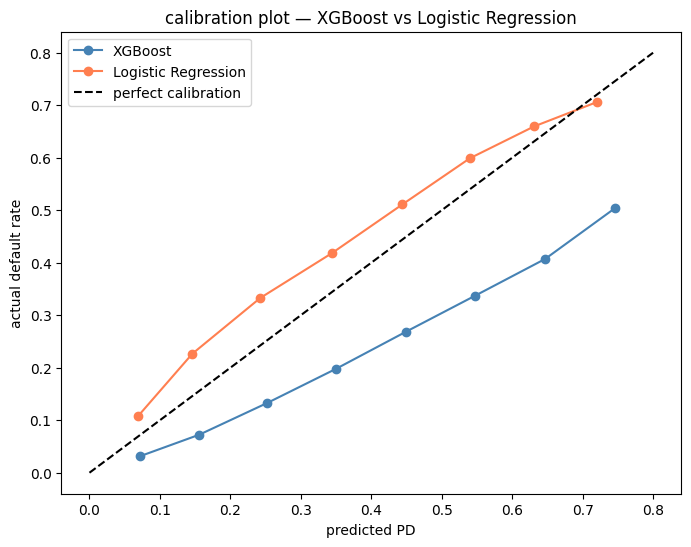

In [40]:
def calc_gini(y_true, y_pred_proba):
    auc = roc_auc_score(y_true, y_pred_proba)
    gini = 2 * auc - 1
    return auc, gini

def calc_ks(y_true, y_pred_proba):
    fpr, tpr, _ = sk.metrics.roc_curve(y_true, y_pred_proba)
    ks = max(tpr - fpr)
    return ks

def calc_psi(train_preds, test_preds, bins=None):
    if bins is None:
        bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    train_dist = (
        pd.Series(pd.cut(train_preds, bins=bins))
        .value_counts(normalize=True)
        .sort_index()
        .rename('train_pct')
    )
    test_dist = (
        pd.Series(pd.cut(test_preds, bins=bins))
        .value_counts(normalize=True)
        .sort_index()
        .rename('test_pct')
    )
    psi_df = pd.concat([train_dist, test_dist], axis=1).replace({0: np.nan}).dropna()
    psi_df['psi'] = (psi_df['test_pct'] - psi_df['train_pct']) * np.log(psi_df['test_pct'] / psi_df['train_pct'])
    return psi_df['psi'].sum(), psi_df

def calibration_summary(y_true, y_pred_proba, bins=None):
    if bins is None:
        bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
    cal_df = pd.DataFrame({'Y_test': y_true, 'y_pred': y_pred_proba})
    cal_df['bins'] = pd.cut(cal_df['y_pred'], bins=bins)
    summary = cal_df.groupby('bins', observed=False)['y_pred'].agg(['count']).reset_index().rename(columns={'count': 'num_loans'})
    summary['defaults'] = cal_df.groupby('bins', observed=False)['Y_test'].agg(['sum']).reset_index()['sum']
    summary['default_rate'] = summary['defaults'] / summary['num_loans']
    summary['avg_pred_pd'] = cal_df.groupby('bins', observed=False)['y_pred'].mean().values
    return summary

summary_xgb = calibration_summary(Y_test_xgb, Y_pred_xgb)
summary_lr  = calibration_summary(Y_test, y_pred)
plt.figure(figsize=(8, 6))
plt.plot(summary_xgb['avg_pred_pd'], summary_xgb['default_rate'], 'o-', color='steelblue', label='XGBoost')
plt.plot(summary_lr['avg_pred_pd'],  summary_lr['default_rate'],  'o-', color='coral',     label='Logistic Regression')
plt.plot([0, 0.8], [0, 0.8], 'k--', label='perfect calibration')
plt.xlabel('predicted PD')
plt.ylabel('actual default rate')
plt.title('calibration plot — XGBoost vs Logistic Regression')
plt.legend()
plt.show()

In [41]:
lr_model.predict_proba(X_train)[:, 1]
lr_train_preds  = lr_model.predict_proba(X_train)[:, 1]
lr_test_preds   = lr_model.predict_proba(X_test)[:, 1]
xgb_train_preds = xgb_model.predict_proba(X_train_xgb)[:, 1]
xgb_test_preds  = xgb_model.predict_proba(X_test_xgb)[:, 1]

lr_auc, lr_gini  = calc_gini(Y_test, y_pred)
xgb_auc, xgb_gini = calc_gini(Y_test_xgb, Y_pred_xgb)
lr_ks = calc_ks(Y_test, y_pred)
xgb_ks = calc_ks(Y_test_xgb, Y_pred_xgb)    
lr_psi, lr_psi_df = calc_psi(lr_train_preds, lr_test_preds)
xgb_psi, xgb_psi_df = calc_psi(xgb_train_preds, xgb_test_preds)
print(f"{'Metric':<10} {'LR':>10} {'XGBoost':>10}")
print(f"{'AUC':<10} {lr_auc:>10.4f} {xgb_auc:>10.4f}")
print(f"{'Gini':<10} {lr_gini:>10.4f} {xgb_gini:>10.4f}")
print(f"{'KS':<10} {lr_ks:>10.4f} {xgb_ks:>10.4f}")
print(f"{'PSI':<10} {lr_psi:>10.4f} {xgb_psi:>10.4f}")

Metric             LR    XGBoost
AUC            0.6842     0.7051
Gini           0.3685     0.4102
KS             0.2625     0.2969
PSI            0.0030     0.0012


In [42]:
X_test_sample = X_test_xgb.sample(1000, random_state=42)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_sample)
shap_df = pd.DataFrame(
    shap_values, 
    columns=X_test_sample.columns
)
shap_df.abs().mean().sort_values(ascending=False)

term                      0.516283
installment               0.486552
loan_amnt                 0.331532
fico_avg                  0.205011
acc_open_past_24mths      0.197308
annual_inc                0.168760
dti                       0.112400
home_ownership            0.105335
mort_acc                  0.075059
inq_last_6mths            0.070567
purpose                   0.063763
emp_length                0.055830
revol_util                0.053383
verification_status       0.039718
credit_hist_months        0.037601
mths_since_last_delinq    0.031239
pub_rec                   0.016799
delinq_2yrs               0.014453
pub_rec_bankruptcies      0.007014
dtype: float32